# Experiment 2: Email Spam/Ham Classification using Naive Bayes and KNN

**Objective**
- Build spam classifiers using Naive Bayes and KNN.
- Compare Gaussian, Multinomial and Bernoulli Naive Bayes.
- Study the effect of varying k.
- Compare KDTree and BallTree.
- Optimize KNN using GridSearchCV and RandomizedSearchCV.
- Evaluate computational complexity and execution time.
- Evaluate using K-Fold Cross Validation.


## Step 1: Import Required Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

## Step 2: Load the Dataset

The dataset has 57 numerical features extracted from emails and a target column `class`
(1 = Spam, 0 = Non-Spam).

In [57]:
df = pd.read_csv(r"C:\Users\tashw\Downloads\spambase_csv.csv")

print("Shape:", df.shape)
df.head()

Shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Step 3: Handle Missing Values

In [58]:
print("Missing values :")
print(df.isnull().sum().sum(), "total missing values")

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Missing values :
0 total missing values
Duplicate rows: 391
Shape after removing duplicates: (4210, 58)


## Step 4: Normalize Features

KNN uses distance calculations, so features are scaled to the same range (0-1)
using Min-Max normalization.

In [59]:
X = df.drop("class", axis=1)
y = df["class"]

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.000000,0.044818,0.125490,0.0,0.032,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.023955,0.000000,0.000000,0.002502,0.006007,0.017487
1,0.046256,0.019608,0.098039,0.0,0.014,0.047619,0.028886,0.006301,0.000000,0.051705,...,0.0,0.000000,0.013536,0.0,0.011454,0.029985,0.002421,0.003735,0.010012,0.064836
2,0.013216,0.000000,0.139216,0.0,0.123,0.032313,0.026135,0.010801,0.121673,0.013751,...,0.0,0.002281,0.014664,0.0,0.008498,0.030651,0.000504,0.008008,0.048458,0.142551
3,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.014048,0.0,0.004218,0.000000,0.000000,0.002303,0.003905,0.011995
4,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.013843,0.0,0.004157,0.000000,0.000000,0.002303,0.003905,0.011995


## Step 5: Exploratory Data Analysis

### 5.1 Class Distribution

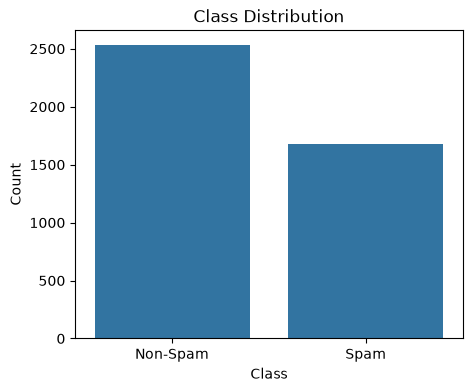

In [60]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.xticks([0,1], ["Non-Spam", "Spam"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 5.2 Correlation Heatmap

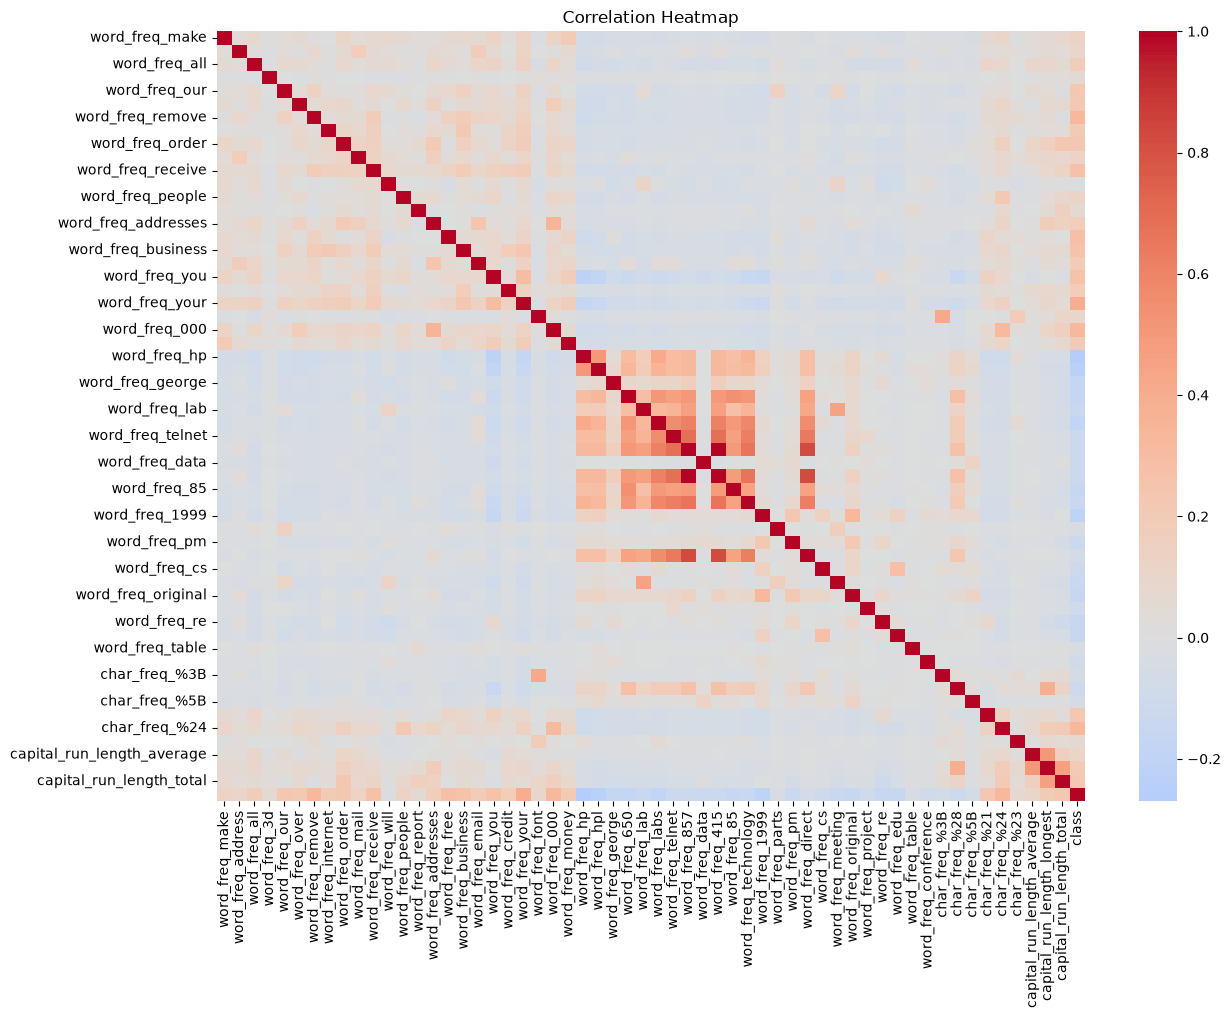

In [61]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### 5.3 Histograms of Important Features

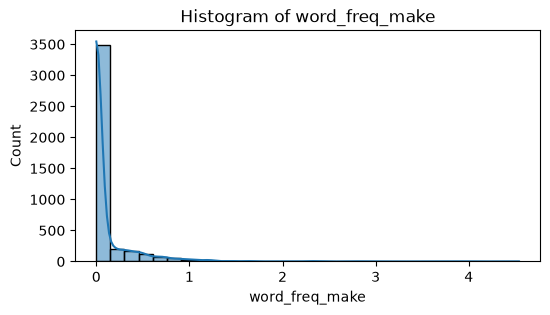

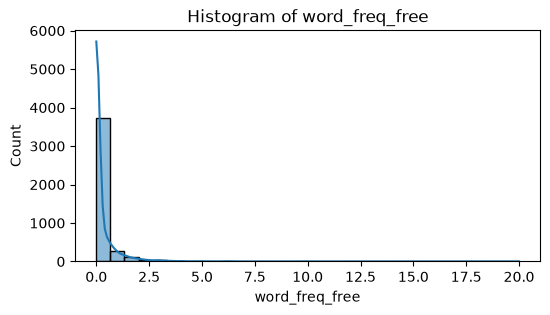

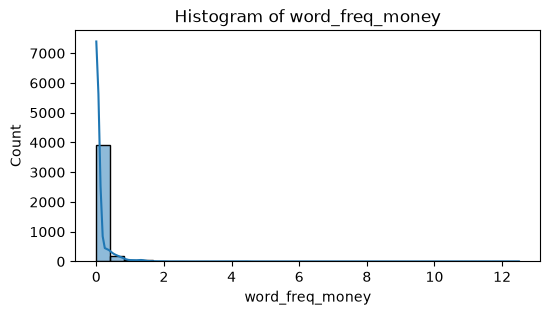

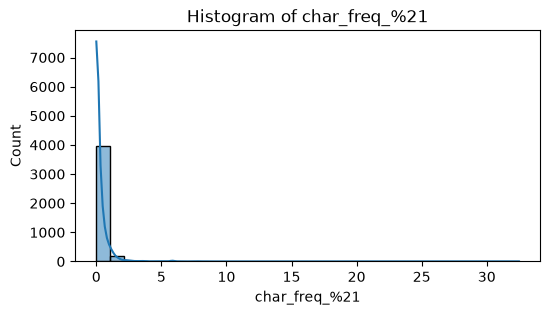

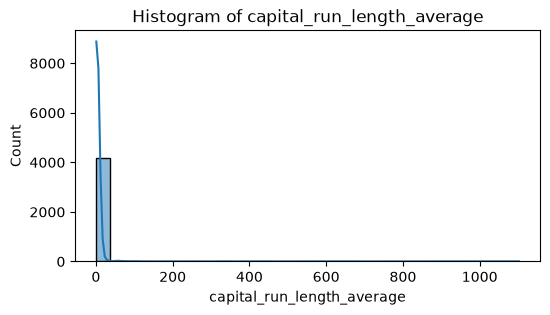

In [62]:
important_features = ["word_freq_make", "word_freq_free",
                      "word_freq_money", "char_freq_%21",
                      "capital_run_length_average"]

for feature in important_features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f"Histogram of {feature}")
    plt.show()

### 5.4 Boxplots

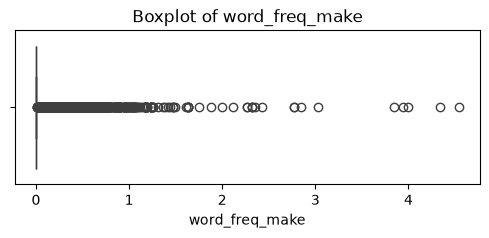

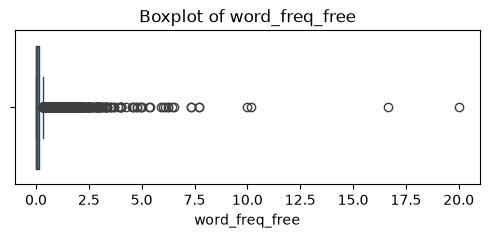

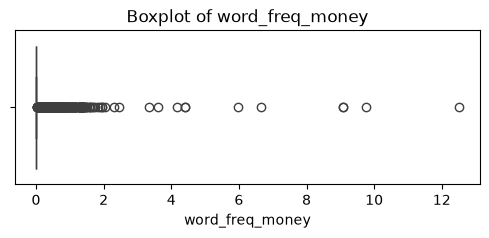

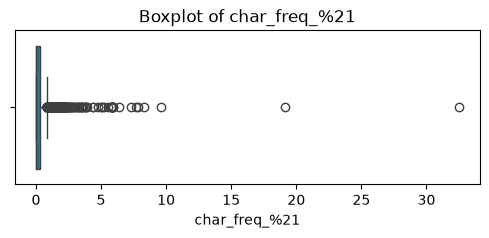

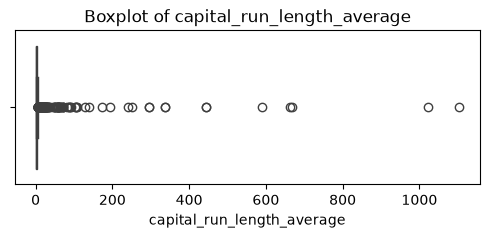

In [63]:
for feature in important_features:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.show()

## Step 6: Train-Test Split

80% of the data is used for training and 20% for testing. `stratify=y` keeps the
spam/non-spam ratio the same in both sets.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (3368, 57)  Test size: (842, 57)


## Step 7: Train Naive Bayes and KNN Models

Four classifiers are trained: Gaussian NB, Multinomial NB, Bernoulli NB, and KNN
(default k=5).

In [65]:
gaussian_nb = GaussianNB().fit(X_train, y_train)
multinomial_nb = MultinomialNB().fit(X_train, y_train)
bernoulli_nb = BernoulliNB().fit(X_train, y_train)
knn_default = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

print("All models trained.")

All models trained.


## Step 8: Naive Bayes Comparison Table

Accuracy, Precision, Recall, F1-score and ROC-AUC are computed for each Naive Bayes variant.

In [66]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

nb_results = {
    "Gaussian": evaluate(gaussian_nb, X_test, y_test),
    "Multinomial": evaluate(multinomial_nb, X_test, y_test),
    "Bernoulli": evaluate(bernoulli_nb, X_test, y_test)
}

nb_comparison = pd.DataFrame(nb_results)
nb_comparison

,Gaussian,Multinomial,Bernoulli
Accuracy,0.828979,0.899050,0.893112
Precision,0.714286,0.953069,0.872727
Recall,0.952381,0.785714,0.857143
F1,0.816327,0.861338,0.864865
ROC-AUC,0.942232,0.966268,0.959916


### 8.1 Confusion Matrix for each Naive Bayes model

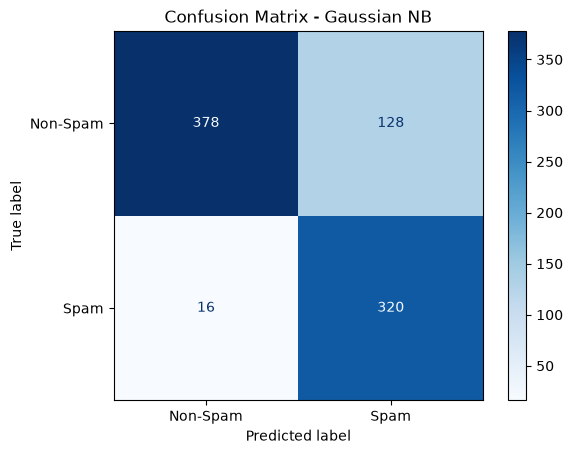

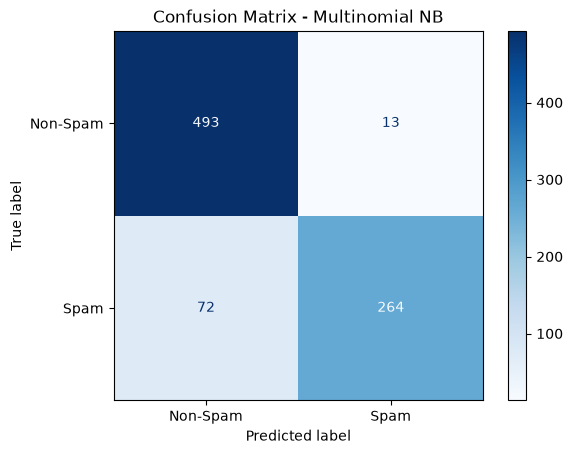

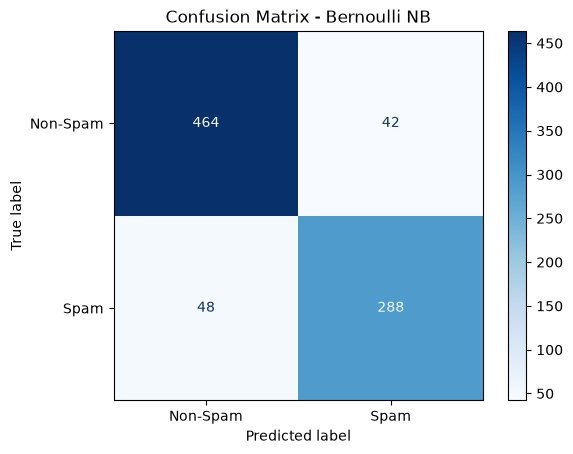

In [67]:
for name, model in [("Gaussian NB", gaussian_nb), ("Multinomial NB", multinomial_nb), ("Bernoulli NB", bernoulli_nb)]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Spam", "Spam"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### 8.2 ROC Curves

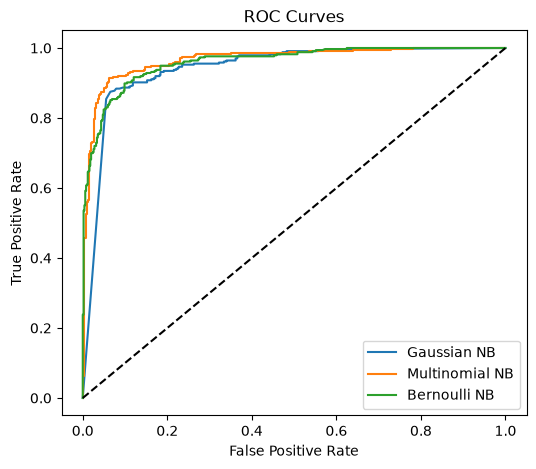

In [68]:
plt.figure(figsize=(6,5))
for name, model in [("Gaussian NB", gaussian_nb), ("Multinomial NB", multinomial_nb), ("Bernoulli NB", bernoulli_nb)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

### 8.3 Precision-Recall Curves

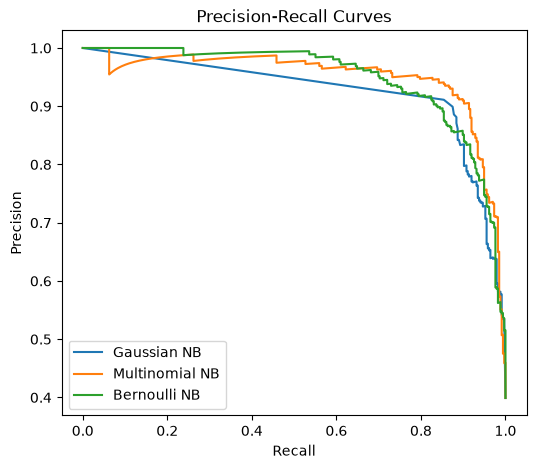

In [69]:
plt.figure(figsize=(6,5))
for name, model in [("Gaussian NB", gaussian_nb), ("Multinomial NB", multinomial_nb), ("Bernoulli NB", bernoulli_nb)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

## Step 9: KNN Comparison for Different Values of k

KNN is trained for k = 1, 3, 5, 7, 9, 11 and evaluated.

In [70]:
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    knn_k_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })
knn_k_table = pd.DataFrame(knn_k_results)
knn_k_table

,k,Accuracy,Precision,Recall,F1
0,1,0.900238,0.879518,0.869048,0.874251
1,3,0.896675,0.900322,0.833333,0.865533
2,5,0.891924,0.896440,0.824405,0.858915
3,7,0.889549,0.898361,0.815476,0.854914
4,9,0.891924,0.899023,0.821429,0.858476
5,11,0.888361,0.900662,0.809524,0.852665


### 9.1 Accuracy vs k Plot

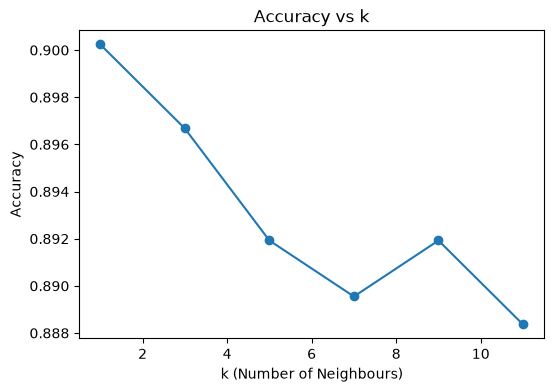

In [71]:
plt.figure(figsize=(6,4))
plt.plot(knn_k_table["k"], knn_k_table["Accuracy"], marker="o")
plt.xlabel("k (Number of Neighbours)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()

## Step 10: Hyperparameter Tuning using GridSearchCV

GridSearchCV exhaustively searches all combinations of `n_neighbors`, `weights`
and `metric` using 5-fold cross validation.

In [72]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}


grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best CV Accuracy: 0.9076595782205545


### 10.1 GridSearchCV Heatmap

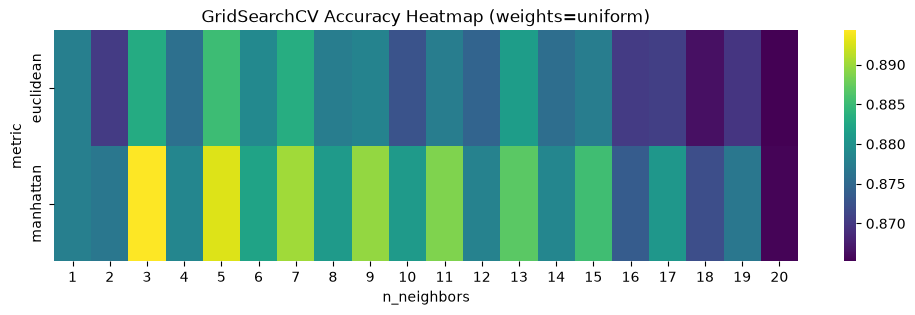

In [73]:
grid_df = pd.DataFrame(grid_search.cv_results_)
grid_df = grid_df[grid_df["param_weights"] == "uniform"]

heatmap_data = grid_df.pivot(index="param_metric", columns="param_n_neighbors", values="mean_test_score")

plt.figure(figsize=(12,3))
sns.heatmap(heatmap_data, annot=False, cmap="viridis")
plt.title("GridSearchCV Accuracy Heatmap (weights=uniform)")
plt.xlabel("n_neighbors")
plt.ylabel("metric")
plt.show()

## Step 11: Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV samples a fixed number of parameter combinations instead of
testing all of them, making it faster than GridSearchCV.

In [74]:
param_dist = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_dist, n_iter=5,
                                    cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)


Best Parameters: {'weights': 'distance', 'n_neighbors': 16, 'metric': 'euclidean'}
Best CV Accuracy: 0.896676381497436


### 11.1 RandomizedSearchCV Score Distribution

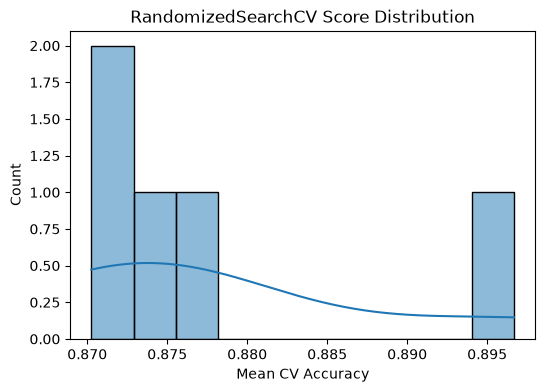

In [75]:
random_df = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(6,4))
sns.histplot(random_df["mean_test_score"], bins=10, kde=True)
plt.title("RandomizedSearchCV Score Distribution")
plt.xlabel("Mean CV Accuracy")
plt.show()

## Step 12: GridSearchCV vs RandomizedSearchCV

In [76]:
grid_vs_random = pd.DataFrame({
    "Parameter": ["Best k", "Metric", "Weights", "CV Accuracy"
                 ],
    "GridSearchCV": [
        grid_search.best_params_["n_neighbors"],
        grid_search.best_params_["metric"],
        grid_search.best_params_["weights"],
        grid_search.best_score_,
        
    ],
    "RandomizedSearchCV": [
        random_search.best_params_["n_neighbors"],
        random_search.best_params_["metric"],
        random_search.best_params_["weights"],
        random_search.best_score_,

    ]
})
grid_vs_random

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,14,16
1,Metric,manhattan,euclidean
2,Weights,distance,distance
3,CV Accuracy,0.90766,0.896676


## Step 13: Classifier Comparison Bar Chart

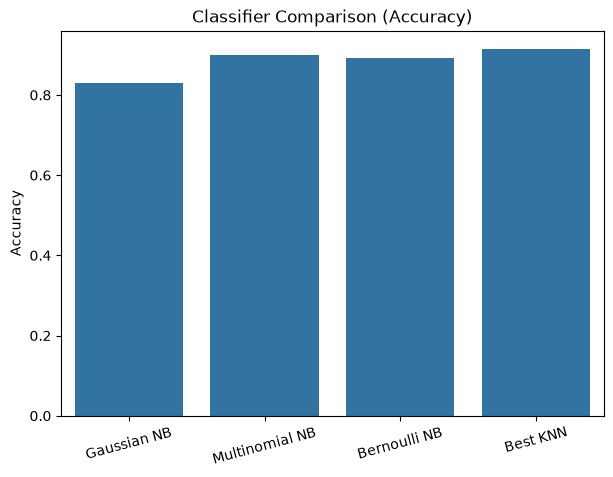

In [77]:
best_knn = grid_search.best_estimator_

overall_accuracy = {
    "Gaussian NB": accuracy_score(y_test, gaussian_nb.predict(X_test)),
    "Multinomial NB": accuracy_score(y_test, multinomial_nb.predict(X_test)),
    "Bernoulli NB": accuracy_score(y_test, bernoulli_nb.predict(X_test)),
    "Best KNN": accuracy_score(y_test, best_knn.predict(X_test))
}

plt.figure(figsize=(7,5))
sns.barplot(x=list(overall_accuracy.keys()), y=list(overall_accuracy.values()))
plt.title("Classifier Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

## Step 14: KDTree vs BallTree

The best KNN parameters found by GridSearchCV are used with `algorithm="kd_tree"`
and `algorithm="ball_tree"` to compare accuracy, training time and prediction time.

In [78]:
best_params = grid_search.best_params_

def time_knn(algorithm):
    model = KNeighborsClassifier(
        n_neighbors=best_params["n_neighbors"],
        weights=best_params["weights"],
        metric=best_params["metric"],
        algorithm=algorithm
    )
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start

    return accuracy_score(y_test, y_pred), train_time, predict_time

kd_accuracy, kd_train_time, kd_predict_time = time_knn("kd_tree")
ball_accuracy, ball_train_time, ball_predict_time = time_knn("ball_tree")

kd_vs_ball = pd.DataFrame({
    "Metric": ["Accuracy", "Training Time (s)", "Prediction Time (s)"],
    "KDTree": [kd_accuracy, kd_train_time, kd_predict_time],
    "BallTree": [ball_accuracy, ball_train_time, ball_predict_time]
})
kd_vs_ball

,Metric,KDTree,BallTree
0,Accuracy,0.914489,0.914489
1,Training Time (s),0.034340,0.013410
2,Prediction Time (s),0.225856,0.104614


### 14.1 Training Time and Prediction Time Comparison

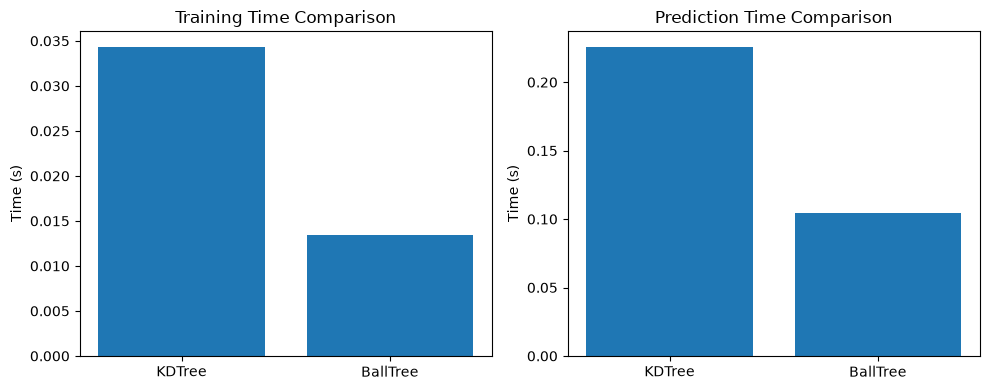

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].bar(["KDTree", "BallTree"], [kd_train_time, ball_train_time])
axes[0].set_title("Training Time Comparison")
axes[0].set_ylabel("Time (s)")

axes[1].bar(["KDTree", "BallTree"], [kd_predict_time, ball_predict_time])
axes[1].set_title("Prediction Time Comparison")
axes[1].set_ylabel("Time (s)")

plt.tight_layout()
plt.show()

## Step 15: 5-Fold Cross Validation

The best Naive Bayes variant and the best KNN model (from GridSearchCV) are
evaluated using 5-fold cross validation.

In [80]:
best_nb_name = nb_comparison.loc["Accuracy"].idxmax()
best_nb_model = {"Gaussian": gaussian_nb, "Multinomial": multinomial_nb, "Bernoulli": bernoulli_nb}[best_nb_name]

print("Best Naive Bayes variant:", best_nb_name)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_fold_scores = []
knn_fold_scores = []

for train_idx, val_idx in skf.split(X_scaled, y):
    X_tr, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    nb_model = best_nb_model.fit(X_tr, y_tr)
    nb_fold_scores.append(accuracy_score(y_val, nb_model.predict(X_val)))

    knn_model = KNeighborsClassifier(
        n_neighbors=best_params["n_neighbors"],
        weights=best_params["weights"],
        metric=best_params["metric"]
    ).fit(X_tr, y_tr)
    knn_fold_scores.append(accuracy_score(y_val, knn_model.predict(X_val)))

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Naive Bayes": nb_fold_scores,
    "Best KNN": knn_fold_scores
})
cv_table.loc["Average"] = ["Average", np.mean(nb_fold_scores), np.mean(knn_fold_scores)]
cv_table

Best Naive Bayes variant: Multinomial


,Fold,Naive Bayes,Best KNN
0,1,0.894299,0.914489
1,2,0.889549,0.922803
2,3,0.894299,0.901425
3,4,0.880048,0.900238
4,5,0.874109,0.904988
Average,Average,0.886461,0.908789


### 15.1 Cross-Validation Accuracy Plot

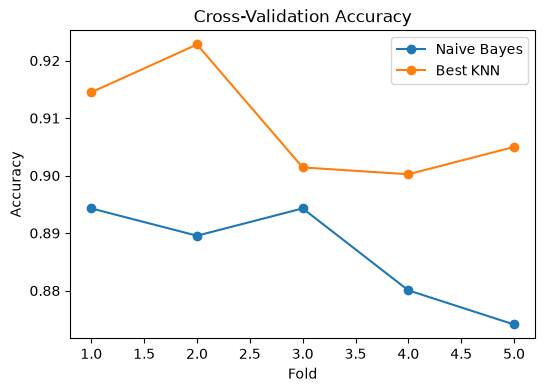

In [81]:
plt.figure(figsize=(6,4))
plt.plot(range(1,6), nb_fold_scores, marker="o", label="Naive Bayes")
plt.plot(range(1,6), knn_fold_scores, marker="o", label="Best KNN")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy")
plt.legend()
plt.show()

## Step 16: Theoretical Time Complexity

n = number of training samples, d = number of features.

In [82]:
theoretical_complexity = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "KNN (Brute)", "KDTree", "BallTree"],
    "Training": ["O(nd)", "O(1)", "O(n log n)", "O(n log n)"],
    "Prediction": ["O(d)", "O(nd)", "O(log n) avg", "O(log n) avg"]
})
theoretical_complexity

,Algorithm,Training,Prediction
0,Naive Bayes,O(nd),O(d)
1,KNN (Brute),O(1),O(nd)
2,KDTree,O(n log n),O(log n) avg
3,BallTree,O(n log n),O(log n) avg


## Step 17: Experimental Time Analysis

In [83]:
def time_model(model):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    model.predict(X_test)
    predict_time = time.time() - start

    return train_time, predict_time

exp_results = []
for name, model in [("Gaussian NB", GaussianNB()), ("Multinomial NB", MultinomialNB()),
                     ("Bernoulli NB", BernoulliNB()),
                     ("Best KNN", KNeighborsClassifier(n_neighbors=best_params["n_neighbors"],
                                                        weights=best_params["weights"],
                                                        metric=best_params["metric"]))]:
    train_t, predict_t = time_model(model)
    exp_results.append({"Algorithm": name, "Training(s)": train_t, "Prediction(s)": predict_t})

experimental_time = pd.DataFrame(exp_results)
experimental_time

,Algorithm,Training(s),Prediction(s)
0,Gaussian NB,0.023052,0.003960
1,Multinomial NB,0.004814,0.001337
2,Bernoulli NB,0.007247,0.004012
3,Best KNN,0.003492,0.041220


## Step 18: Additional Tasks

### 18.1 Different Train-Test Splits

In [84]:
for test_size in [0.1, 0.2, 0.3]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"],
                                  weights=best_params["weights"],
                                  metric=best_params["metric"]).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    print(f"Test size {int(test_size*100)}% -> Accuracy: {acc:.4f}")

Test size 10% -> Accuracy: 0.9240
Test size 20% -> Accuracy: 0.9145
Test size 30% -> Accuracy: 0.9034


### 18.2 Euclidean vs Manhattan Distance

In [85]:
for metric in ["euclidean", "manhattan"]:
    model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=metric).fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{metric.capitalize()} distance -> Accuracy: {acc:.4f}")

Euclidean distance -> Accuracy: 0.8884
Manhattan distance -> Accuracy: 0.8907


### 18.3 Weighted KNN (uniform vs distance)

In [86]:
for weight in ["uniform", "distance"]:
    model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], weights=weight).fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Weights = {weight} -> Accuracy: {acc:.4f}")

Weights = uniform -> Accuracy: 0.8884
Weights = distance -> Accuracy: 0.9074


### 18.4 Overfitting (small k) vs Underfitting (large k)

Refer to the "Accuracy vs k" table and plot from Step 9. A very small k (e.g. k=1) tends to
overfit the training data since a single nearby point decides the prediction. A very large k
tends to underfit, since the decision boundary becomes too smooth and starts including
points from the other class in the neighbourhood. The best k is the one where test accuracy
is highest before it starts to plateau or decline.

## Step 19: Analysis Questions

**1. Which Naive Bayes variant performed best?**
See the `nb_comparison` table in Step 8. The variant with the highest Accuracy/F1/ROC-AUC
is the best performer for this dataset (typically Bernoulli or Multinomial NB perform
better than Gaussian NB on Spambase, since many features behave like word-presence
indicators rather than normally distributed values).

**2. What is the optimal value of k?**
The optimal k is the value chosen by GridSearchCV/RandomizedSearchCV (see Step 10/11
`best_params_`), which is also visible as the peak in the "Accuracy vs k" plot in Step 9.

**3. Compare GridSearchCV and RandomizedSearchCV.**
GridSearchCV tests every combination in the grid, so it is exhaustive but slower.
RandomizedSearchCV samples a fixed number of random combinations, so it is faster but
may miss the true optimum. Compare `grid_vs_random` table in Step 12 for the actual
CV accuracy and execution time difference.

**4. Compare KDTree and BallTree.**
Both give the same accuracy since they use the same KNN logic, just different indexing
structures for the neighbour search. Their training/prediction times differ slightly
based on feature dimensionality and data distribution (see `kd_vs_ball` table in Step 14).

**5. Compare theoretical and practical complexity.**
See `theoretical_complexity` and `experimental_time` tables in Step 16/17. In practice
KNN has near-zero training time (it just stores data) but slower prediction time
compared to Naive Bayes, which matches the theoretical complexity.

**6. Which classifier is preferred for large datasets?**
Naive Bayes is generally preferred for large datasets since both training and prediction
are linear in the number of features and do not require storing/searching the entire
training set at prediction time, unlike KNN.